# Diabetes Prediction Project

## Overview
The goal of this project is to build a machine learning model that predicts whether a patient has diabetes based on medical measurements.

This is a **binary classification** problem:
- `0` = No Diabetes
- `1` = Diabetes

## Dataset Description
The dataset includes these features:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

The target column is:
- Outcome

## Project Objective
The main steps in this notebook are:
1. Load and inspect the dataset
2. Clean missing or unrealistic values
3. Explore the data with charts
4. Scale the features
5. Train machine learning models
6. Evaluate and compare the models
7. Review the most important features


## 1. Import Libraries and Load Data

This cell imports the Python libraries used in the project.

- `pandas` and `numpy` help with data cleaning and calculations.
- `matplotlib` and `seaborn` are used for visualizations.
- The dataset is loaded from `diabetes.csv` into a DataFrame called `df`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('diabetes.csv')

# Display the full dataset preview
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## 2. Check Dataset Size

This cell shows the number of rows and columns in the dataset.

This helps us understand how much data we are working with before cleaning or modeling.


In [2]:
df.shape


(768, 9)

## 3. Check Column Information

This cell shows the data type of each column and whether any values are missing.

This is useful because machine learning models need clean numerical data.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 4. Summary Statistics

This cell gives basic statistics for each numerical column, such as the mean, minimum, maximum, and quartiles.

This helps identify unusual values. For example, some medical columns have a minimum value of `0`, which may not make sense medically.


In [4]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 5. Check for Missing Values

This cell checks if there are any blank or missing values in the dataset.

At first, the dataset may show no missing values, but some columns still contain unrealistic zeros that should be treated like missing data.


In [5]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Missing Values Observation

The dataset does not show missing values at first.

However, columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` contain zero values. In this dataset, those zeros are not realistic medical measurements.

Because of that, these zeros will be replaced with `NaN`, which means missing value.


## 6. Replace Unrealistic Zeros

This cell replaces `0` values with `NaN` in the medical columns where zero is not realistic.

This makes the data cleaning step more accurate because these zeros are treated as missing values instead of real measurements.


In [6]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)


## 7. Recheck Missing Values

After replacing unrealistic zeros, this cell checks how many missing values are now in each column.

This confirms which columns need to be filled before training the model.


In [7]:
df.isnull().sum()


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 8. Fill Missing Values

This cell fills the missing values using the median of each column.

The median is a good choice because it is less affected by outliers than the mean.


In [8]:
df.fillna(df.median(), inplace=True)


## 9. Check the Target Variable

This cell counts how many patients are in each outcome group.

This helps us see whether the dataset is balanced between patients with diabetes and patients without diabetes.


In [9]:
df['Outcome'].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

## 10. Outcome Distribution Chart

This chart shows the number of patients in each class.

It helps us visually see that there are more patients without diabetes than with diabetes in this dataset.


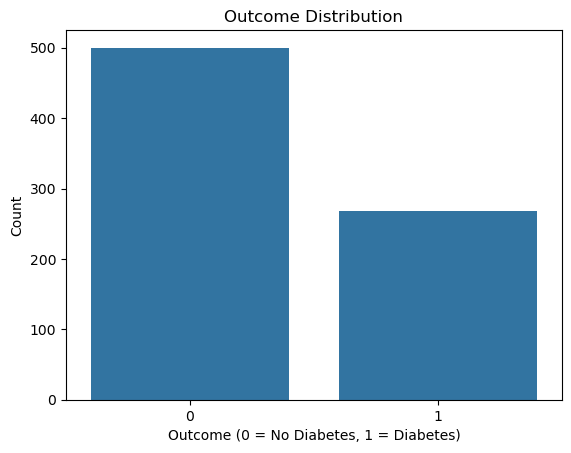

In [10]:
sns.countplot(x='Outcome', data=df)
plt.title('Outcome Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.show()


## 11. Glucose vs Outcome

This boxplot compares glucose levels for patients with and without diabetes.

The goal is to see whether glucose levels are generally higher for patients who have diabetes.


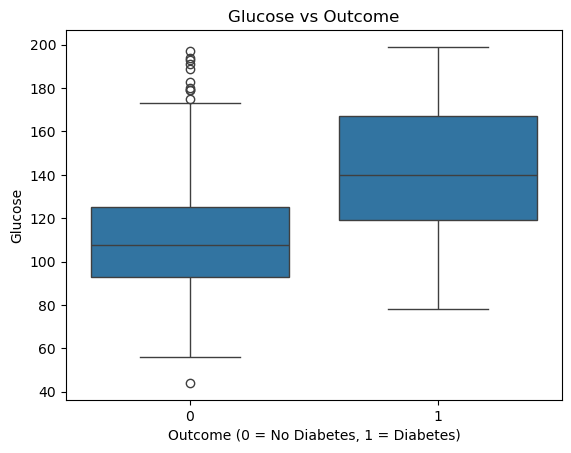

In [11]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose vs Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Glucose')
plt.show()


## 12. BMI vs Outcome

This boxplot compares BMI values for patients with and without diabetes.

This helps us see whether BMI may be related to diabetes prediction.


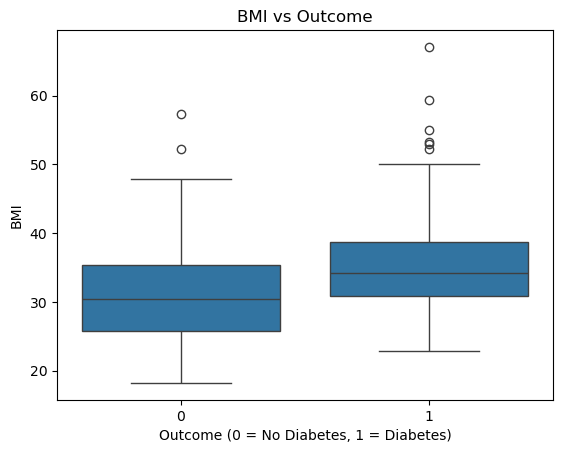

In [12]:
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('BMI vs Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('BMI')
plt.show()


## 13. Age Distribution by Outcome

This chart compares age distributions for both outcome groups.

It helps us see if diabetes appears more often in certain age ranges.


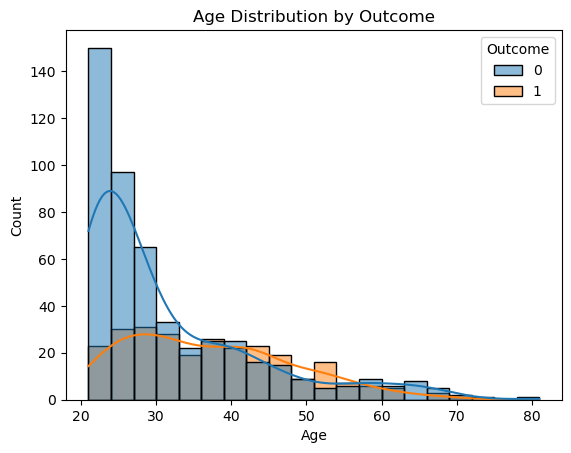

In [13]:
sns.histplot(data=df, x='Age', hue='Outcome', kde=True, bins=20)
plt.title('Age Distribution by Outcome')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


## 14. Correlation Heatmap

This heatmap shows the correlation between each feature and the other features.

Darker or stronger colors show stronger relationships. This helps identify which variables may be connected to `Outcome`.


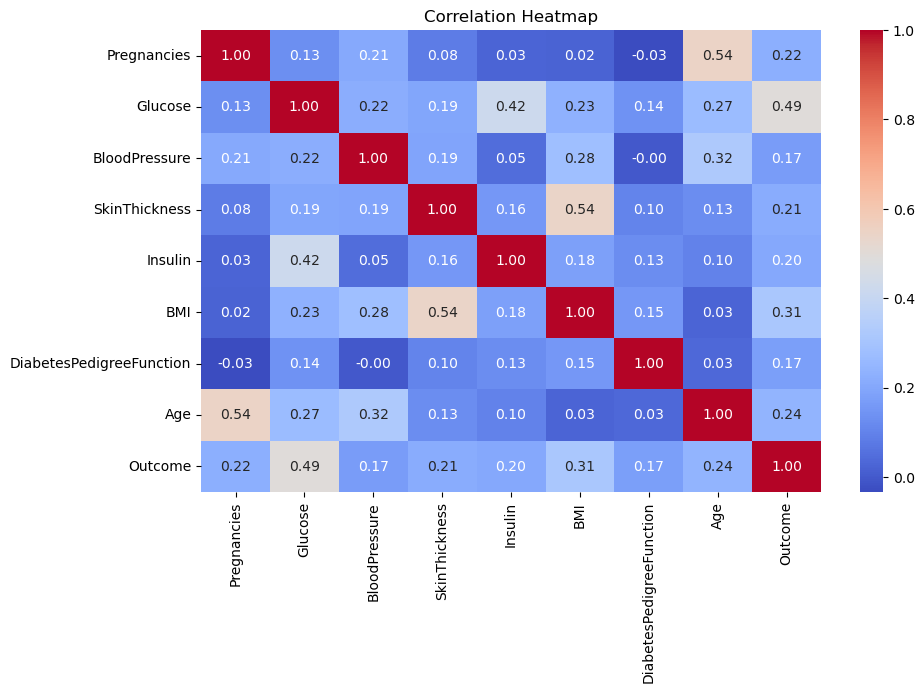

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## Visualization Insights

The visualizations show that `Glucose`, `BMI`, and `Age` appear to be useful predictors of diabetes.

The boxplots show higher glucose and BMI values for many patients with diabetes. The correlation heatmap also helps show which features have stronger relationships with the target variable.


## Feature Scaling

Feature scaling is important because the columns use different ranges.

For example, `Glucose` values are much larger than values like `DiabetesPedigreeFunction`. Scaling helps put the features on a similar scale so one large-number column does not dominate the model.

For this project, standardization is used. This changes the features so they have a mean around 0 and a standard deviation around 1.


## 15. Preview Columns Before Scaling

This cell shows a small preview of `Glucose` and `BMI` before scaling.

This makes it easier to understand that the original values are still in their natural medical measurement ranges.


In [15]:
df[['Glucose', 'BMI']].head()


,Glucose,BMI
0,148.0,33.6
1,85.0,26.6
2,183.0,23.3
3,89.0,28.1
4,137.0,43.1


## 16. Separate Features and Target

This cell separates the dataset into:

- `X`: the input features used to make predictions
- `y`: the target column we want to predict

The model will learn patterns from `X` to predict `y`.


In [16]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


## 17. Apply StandardScaler

This cell scales all feature columns using `StandardScaler`.

The scaled data is then converted back into a DataFrame so the column names are easier to read later.


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


## 18. Preview Scaled Data

This cell displays the first few rows of the scaled dataset.

The values now look different because they were standardized, but they still represent the same original features.


In [18]:
X_scaled.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


## 19. Feature Summary Table

This cell creates a summary table for the dataset.

The table shows each feature, its data type, missing values, and number of unique values. This is a quick way to confirm the dataset is ready for modeling.


In [19]:
summary = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})

summary


,Feature,Data Type,Missing Values,Unique Values
0,Pregnancies,int64,0,17
1,Glucose,float64,0,135
2,BloodPressure,float64,0,46
3,SkinThickness,float64,0,50
4,Insulin,float64,0,185
5,BMI,float64,0,247
6,DiabetesPedigreeFunction,float64,0,517
7,Age,int64,0,52
8,Outcome,int64,0,2


## Feature Summary Explanation

All features in this dataset are numerical.

After replacing unrealistic zeros and filling missing values, there are no remaining missing values. Since the features have different ranges, scaling was applied before training the models.


## Outliers

An outlier is a data point that is very different from the other values.

Some features, especially `Insulin`, `BMI`, and `Glucose`, may contain outliers. These values are not removed because they may still be real medical values. Removing them without a strong reason could remove useful information.


## Class Imbalance

The `Outcome` column shows a small imbalance.

There are more patients labeled `0` than patients labeled `1`. This imbalance is not extreme, but it is still important to look at more than just accuracy when evaluating the model.


## Problem Formulation

This project is a binary classification problem.

The goal is to predict whether a patient has diabetes based on the medical features.

There are no ID columns or unnecessary duplicated columns to remove. The target variable `Outcome` is already encoded as:
- `0` = No Diabetes
- `1` = Diabetes

Because of that, no extra target encoding is needed.


## 20. Define Final X and y

This cell defines the final feature set and target variable again before modeling.

This keeps the machine learning section clear and organized.


In [20]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


## Data Splitting

The dataset is split into training and testing sets.

- The training set is used to teach the model.
- The test set is used to evaluate how well the model performs on data it has not seen before.

The test size is set to 20%, meaning 80% of the data is used for training and 20% is used for testing.


## 21. Train-Test Split

This cell splits the scaled feature data and target labels into training and testing groups.

`random_state=42` makes the split repeatable, so the same results can be produced again.


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


## Model Training: Logistic Regression

Logistic Regression is used first because it is a simple and common model for binary classification.

It is a good baseline model because it is easy to understand and works well for many classification problems.


## 22. Train Logistic Regression

This cell creates and trains the Logistic Regression model.

The model learns patterns from the training data so it can predict diabetes outcomes on new data.


In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Evaluation

The model is evaluated using:

- Accuracy: overall percent of correct predictions
- Confusion matrix: shows correct and incorrect predictions for each class
- Precision, recall, and F1-score: helpful when classes are not perfectly balanced


## 23. Evaluate Logistic Regression

This cell makes predictions on the test set and prints the model's performance.

The confusion matrix and classification report help us understand where the model is correct and where it makes mistakes.


In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.7532467532467533

Confusion Matrix:
[[82 17]
 [21 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



## 24. Logistic Regression Confusion Matrix Chart

This chart makes the confusion matrix easier to read visually.

It shows how many predictions were correct and how many were incorrect for each outcome class.


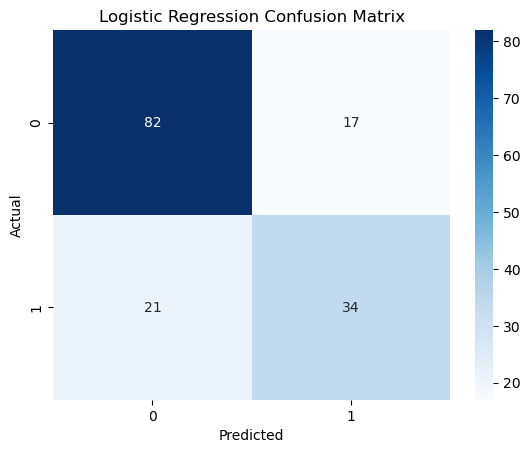

In [26]:
log_cm = confusion_matrix(y_test, y_pred)

sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Random Forest Model

A Random Forest model is also trained to compare performance.

Random Forest combines many decision trees. It can find more complex patterns than Logistic Regression, which can sometimes improve performance on tabular datasets.


## 25. Train and Evaluate Random Forest

This cell trains the Random Forest model and evaluates it on the test set.

The same metrics are used so we can compare it fairly against Logistic Regression.


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, rf_pred))

print('\nClassification Report:')
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.7402597402597403

Confusion Matrix:
[[78 21]
 [19 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



## 26. Random Forest Confusion Matrix Chart

This chart shows the Random Forest confusion matrix visually.

It helps compare how well Random Forest predicted each class.


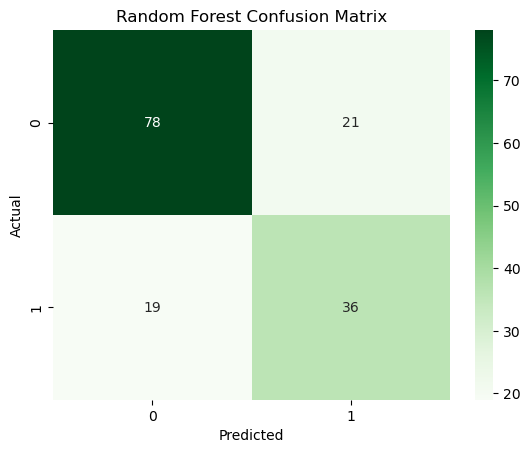

In [30]:
rf_cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 27. Compare Model Accuracy

This cell stores the accuracy scores for both models.

Comparing the scores helps decide which model performed better on the test data.


In [31]:
log_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print('Logistic Regression Accuracy:', log_acc)
print('Random Forest Accuracy:', rf_acc)


Logistic Regression Accuracy: 0.7532467532467533
Random Forest Accuracy: 0.7402597402597403


## 28. Model Comparison Chart

This bar chart compares the accuracy of Logistic Regression and Random Forest.

It gives a quick visual summary of which model performed better.


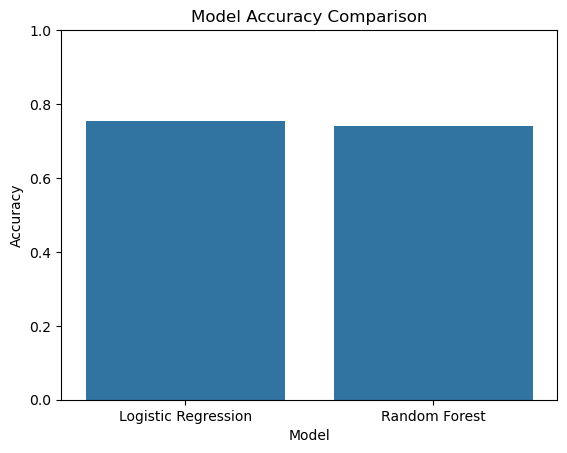

In [32]:
model_scores = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_acc, rf_acc]
})

sns.barplot(x='Model', y='Accuracy', data=model_scores)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()


## Model Comparison

Both Logistic Regression and Random Forest were tested on the same training and testing split.

The better model can be chosen based on accuracy and the classification report. Random Forest may perform better because it can capture more complex relationships in the dataset.


## Important Features

Feature importance helps show which columns had the strongest effect on the Random Forest model's predictions.

This is useful because it connects the machine learning results back to the medical features in the dataset.


## 29. Random Forest Feature Importance

This cell calculates feature importance from the Random Forest model.

The bar chart shows which features the model used the most when making predictions.


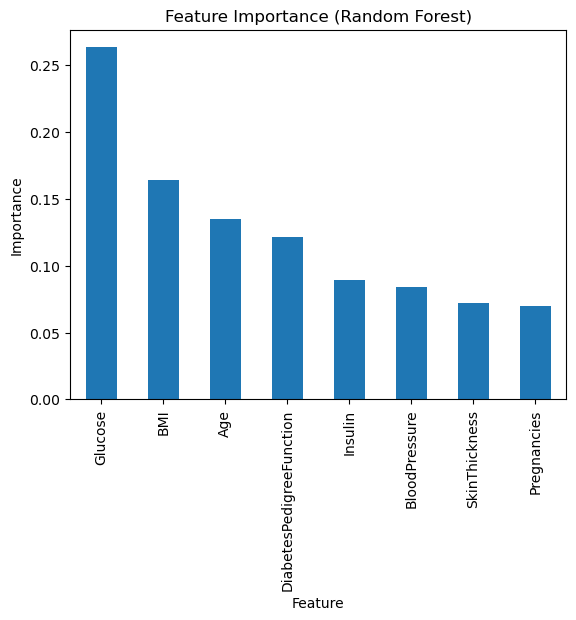

In [33]:
importance = rf_model.feature_importances_
features = X.columns

feat_importance = pd.Series(importance, index=features).sort_values(ascending=False)

feat_importance.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()


## Feature Importance Explanation

The Random Forest model shows which features were most useful for predicting diabetes.

Features like `Glucose`, `BMI`, and `Age` are expected to be important because they showed strong patterns in the earlier charts as well.


## Final Conclusion

In this project, I built a machine learning workflow to predict diabetes using medical data.

First, I inspected the dataset and found that some columns had unrealistic zero values. These zeros were treated as missing values and filled using the median. Then, I explored the data with charts and found that features like `Glucose`, `BMI`, and `Age` showed important patterns related to diabetes.

After cleaning and scaling the data, I trained two models: Logistic Regression and Random Forest. Logistic Regression was useful as a simple baseline model, while Random Forest was added for comparison because it can capture more complex patterns.

Overall, this project shows how data cleaning, visualization, feature scaling, model training, and model evaluation work together in a full machine learning project. The final results suggest that diabetes prediction can be improved by using important medical features such as glucose level, BMI, and age.
